In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [2]:
CSV_PATH = "google.csv" 
CLOSE_COL = "close"           
WINDOW = 60                   
BATCH_SIZE = 32
EPOCHS = 30
TEST_RATIO = 0.2
RANDOM_SEED = 42

In [3]:
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [4]:
def create_sequences(series, window, output_steps=1):
    X, y = [], []
    total_len = len(series)
    for i in range(total_len - window - output_steps + 1):
        X.append(series[i:i+window])
        y.append(series[i+window:i+window+output_steps])
    X = np.array(X)  # (samples, window, features)
    y = np.array(y)  # (samples, output_steps, features) if features>1
    # For single-feature series and output_steps=1, flatten y to (samples,1)
    if y.shape[-1] == 1:
        y = y.reshape((y.shape[0], y.shape[1]))  # (samples, output_steps)
    return X, y

In [5]:
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}. Put your Google stock CSV at this path or change CSV_PATH.")

df = pd.read_csv(CSV_PATH)
if CLOSE_COL not in df.columns:
    raise KeyError(f"Column '{CLOSE_COL}' not found in CSV. Columns available: {df.columns.tolist()}")

prices = df[CLOSE_COL].astype(float).values.reshape(-1, 1)

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices)

# --- Create sequences ---
X_all, y_all = create_sequences(prices_scaled, window=WINDOW, output_steps=1)

In [7]:
split_idx = int(X_all.shape[0] * (1 - TEST_RATIO))
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

In [8]:
model = Sequential([
    Input(shape=(WINDOW, 1)),
    SimpleRNN(60), 
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60)             │         3,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,781 (14.77 KB)

 Trainable params: 3,781 (14.77 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Epoch 1/30
131/131 - 1s - 10ms/step - loss: 0.0067 - val_loss: 1.0839e-04
Epoch 2/30
131/131 - 0s - 3ms/step - loss: 7.8210e-04 - val_loss: 5.9359e-05
Epoch 3/30
131/131 - 0s - 3ms/step - loss: 5.7769e-04 - val_loss: 4.7694e-05
Epoch 4/30
131/131 - 1s - 5ms/step - loss: 4.8970e-04 - val_loss: 4.2025e-05
Epoch 5/30
131/131 - 1s - 5ms/step - loss: 4.3733e-04 - val_loss: 3.7725e-05
Epoch 6/30
131/131 - 1s - 4ms/step - loss: 3.9787e-04 - val_loss: 3.4616e-05
Epoch 7/30
131/131 - 1s - 4ms/step - loss: 3.6678e-04 - val_loss: 3.2126e-05
Epoch 8/30
131/131 - 0s - 4ms/step - loss: 3.4137e-04 - val_loss: 3.0053e-05
Epoch 9/30
131/131 - 0s - 4ms/step - loss: 3.1995e-04 - val_loss: 2.8426e-05
Epoch 10/30
131/131 - 0s - 4ms/step - loss: 3.0152e-04 - val_loss: 2.7211e-05
Epoch 11/30
131/131 - 1s - 4ms/step - loss: 2.8551e-04 - val_loss: 2.6245e-05
Epoch 12/30
131/131 - 0s - 4ms/step - loss: 2.7162e-04 - val_loss: 2.5369e-05
Epoch 13/30
131/131 - 0s - 4ms/step - loss: 2.5957e-04 - val_loss: 2.4522e-0

In [10]:
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE)

y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)
y_pred_orig = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(-1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [11]:
rmse = math.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 14.1206


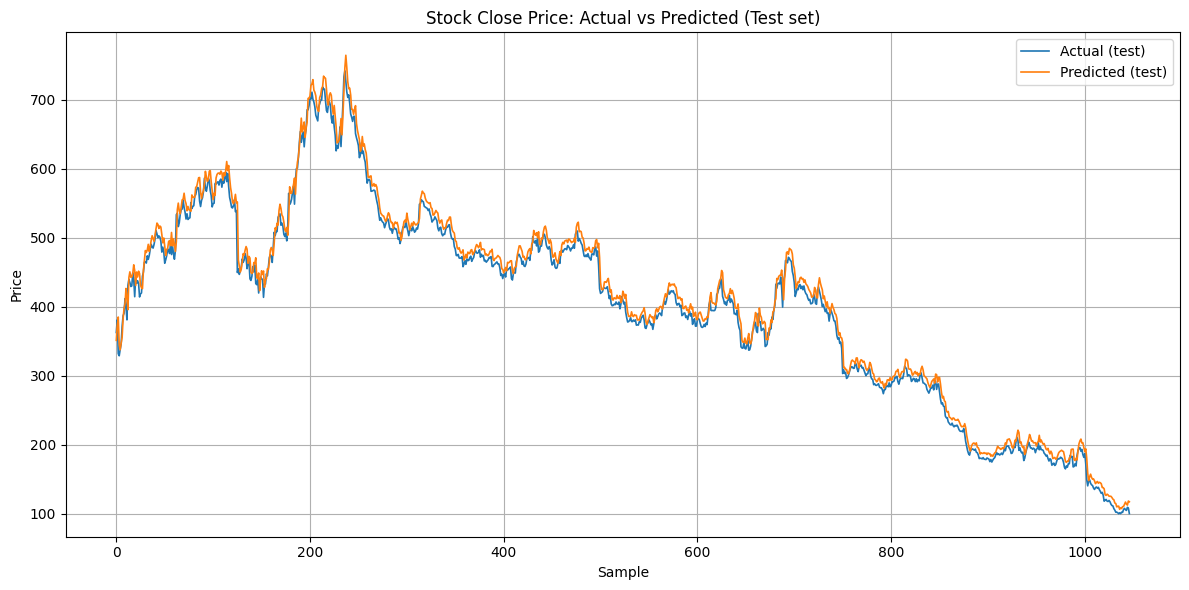

In [12]:
plt.figure(figsize=(12,6))
plt.plot(y_test_orig, label='Actual (test)', linewidth=1.2)
plt.plot(y_pred_orig, label='Predicted (test)', linewidth=1.2)
plt.title('Stock Close Price: Actual vs Predicted (Test set)')
plt.xlabel('Sample')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()